In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# replacing blanks with 0 as tensure is 0 and no total charges are recorded

In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(" " , "0")
df['TotalCharges'] = df['TotalCharges'].astype('float')
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
df['customerID'].duplicated().sum()

np.int64(0)

# converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [5]:
# this means Create a function named conv that accepts one input called value
def conv(value):
    if value == 1:
        return "Yes"
    else:
        return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

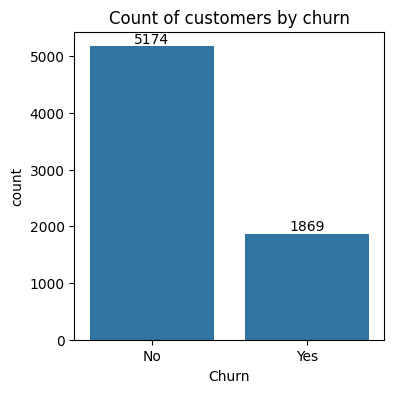

In [7]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = 'Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title('Count of customers by churn')
plt.show()


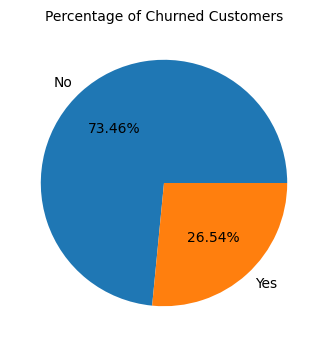

In [10]:
plt.figure(figsize = (4,4))
gb = df.groupby('Churn').agg({'Churn' : 'count'})
plt.pie(gb['Churn'] , labels =gb.index , autopct = "%1.2f%%" )
plt.title('Percentage of Churned Customers',fontsize = 10)
plt.show()

# from the given pie chart we can conclude that 26.54 % of our customers have churned out. #not lets explore the reason behind it

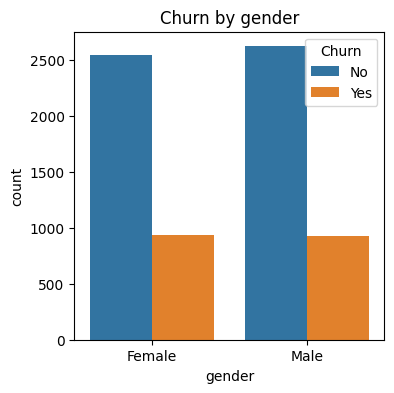

In [11]:
plt.figure(figsize = (4,4))
sns.countplot(x = 'gender' , data = df , hue = 'Churn')
plt.title('Churn by gender')
plt.show()

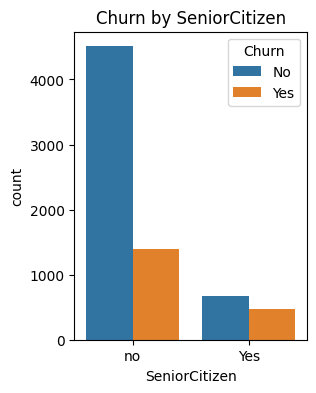

In [12]:
plt.figure(figsize = (3,4))
sns.countplot(x = 'SeniorCitizen' , data = df , hue = 'Churn')
plt.title('Churn by SeniorCitizen')
plt.show()

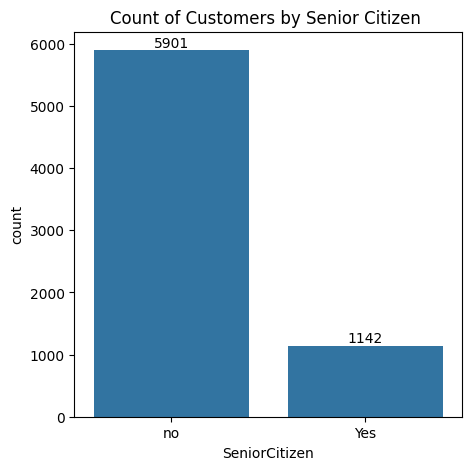

In [36]:
plt.figure(figsize = (5,5))
ax = sns.countplot(x = 'SeniorCitizen' , data = df)
ax.bar_label(ax.containers[0])
 
plt.title('Count of Customers by Senior Citizen ')
plt.show()

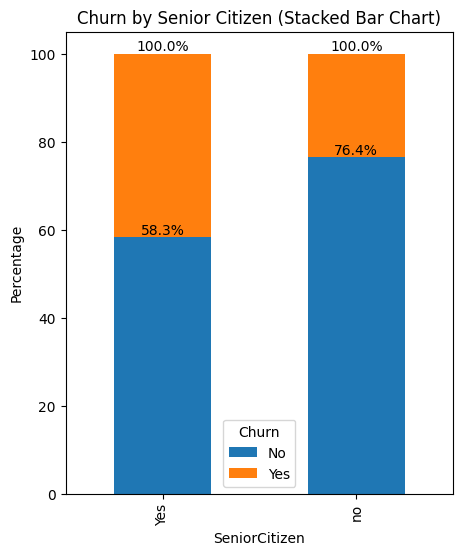

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# create percentage table
ct = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'   # converts to %
) * 100

# stacked bar chart
ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(5,6)
)

# add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.show()


# comparative a greated percentage of people in senior citizen category have churned

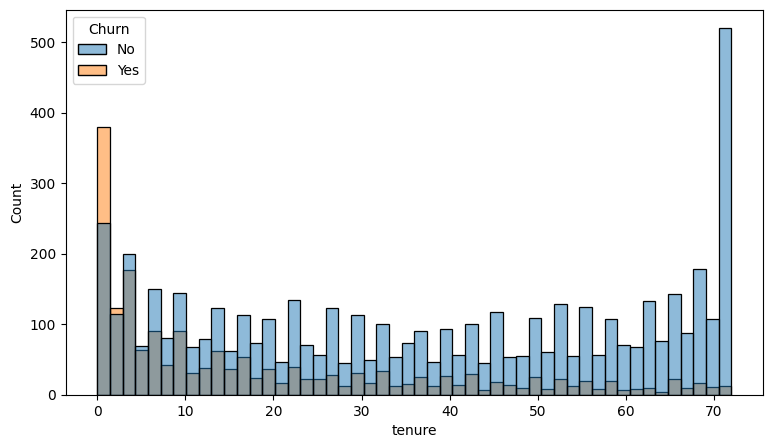

In [16]:
plt.figure(figsize =(9,5))
sns.histplot(x = 'tenure' , data =df , bins = 50 , hue = 'Churn')
plt.show()

# people who have used our services for long time have stayed and people who have used our services #1 or 2 months have churned

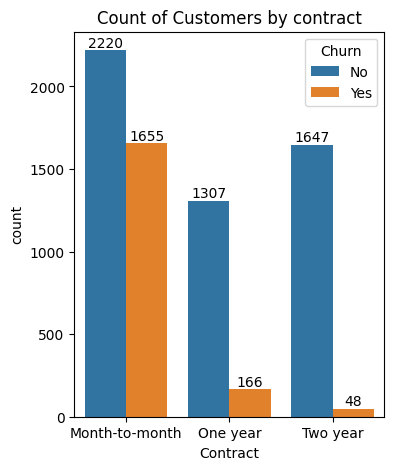

In [34]:
plt.figure(figsize = (4,5))
ax = sns.countplot(x = 'Contract' , data = df , hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Count of Customers by contract')
plt.show()


# people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract

In [18]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

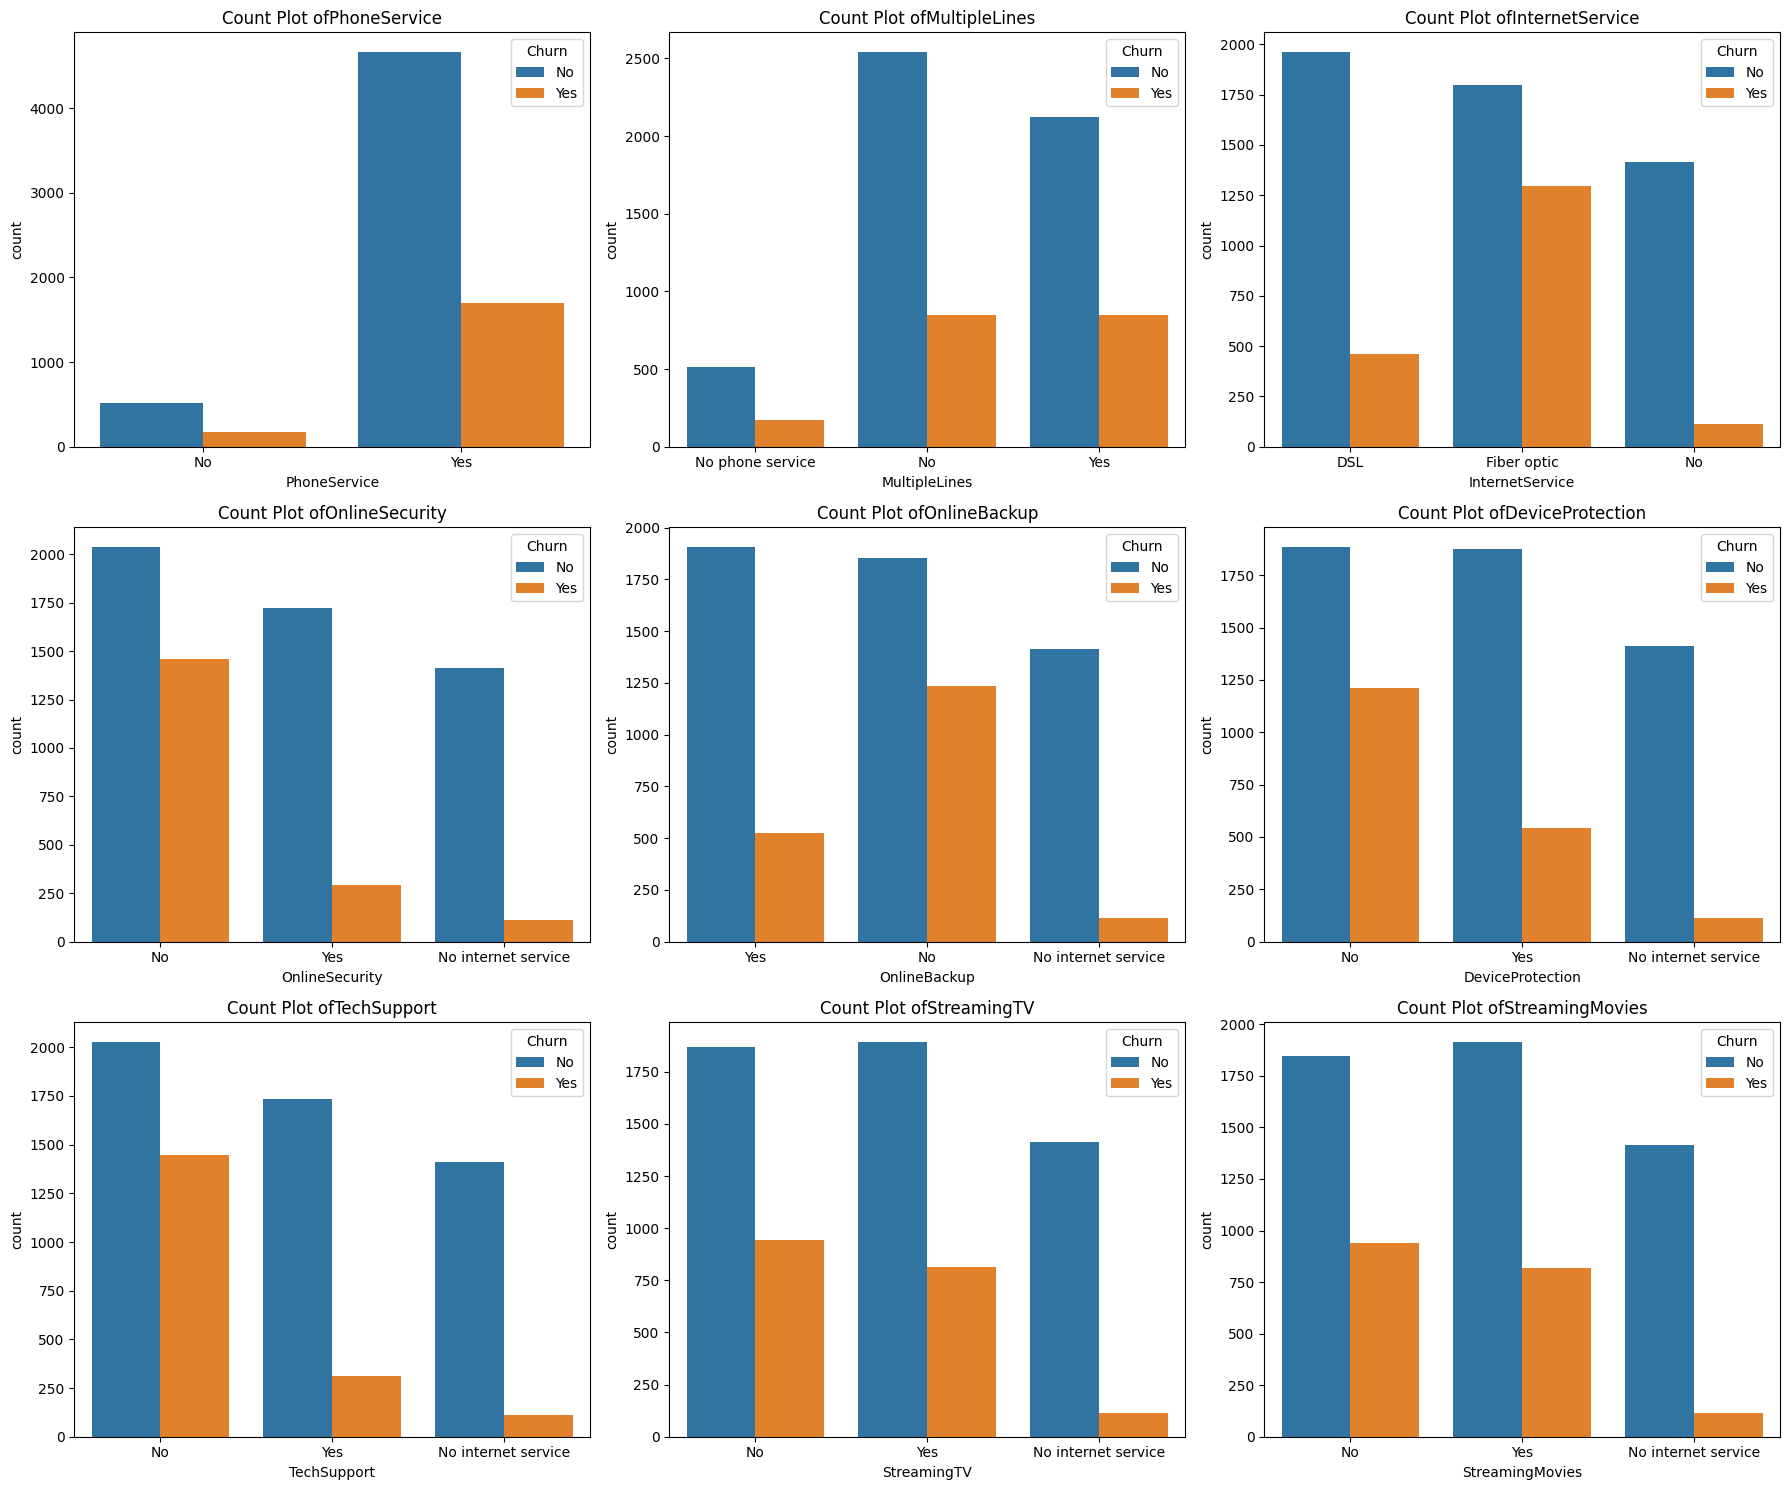

In [26]:
# columns you want to plot
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# flatten axes for easy looping
axes = axes.flatten()

# loop through columns
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, ax=axes[i] ,hue = df['Churn'])

    axes[i].set_title(f'Count Plot of{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
  

# adjust spacing
plt.tight_layout()

plt.show()

# The visualizations present count plots showing customer churn yes/no across various service features such as PhoneService , Multiplelines , InternetService and Online security . the majority of customers who do not churn tend to have services like phoneservice internetservice and onlinesecurity enabled for services like onlinebackup techsupport and streaming tv , churn rates are noticebly higher when these services are not used or are unavailable the charts emphasize the relationship usage and customer churn.

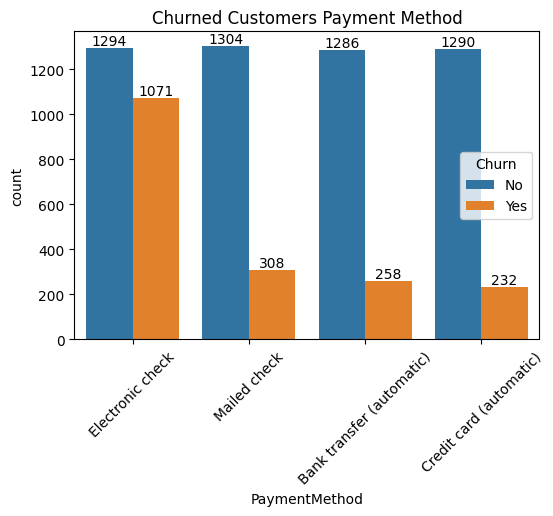

In [33]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = 'PaymentMethod' , data = df , hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churned Customers Payment Method')
plt.xticks(rotation = 90/2)
plt.show()


# Customer is likely to churn when he i using electronic check as a payment method